<!-- HTML file automatically generated from DocOnce source (https://github.com/doconce/doconce/)
doconce format html Firstmidterm2022.do.txt --no_mako -->
<!-- dom:TITLE: PHY321: Classical Mechanics 1 -->

In [2]:
import numpy as np
from math import *
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline
plt.style.use('seaborn-v0_8-colorblind')

## Exercise 3, Model your own system (30 points)

In this problem, you will choose a one dimensional system of your own. You may choose a known potential, or you may invent your own. Your potential must:

1. Have at least one stable equilibrium point.
2. Have at least one unstable equilibrium point, or some other interesting feature (e.g., asymptotic behavior).
3. For some choice of total energy, it should have oscillatory motion (i.e., classical turning points).
4. Produce a non-linear and conservative force.
5. Be continuous and differentiable over the range of interest.

For this problem, you will need to perform the following tasks:

* **3a. (5 pts)** Write down the potential and start to demonstrate that it meets the above criteria. **Make sure it is conservative and that the force is nonlinear before proceeding.**
* **3b. (5 pts)** Sketch or plot the potential and find the equilibrium points. You need to show you can compute the equilibrium points and characterize their stability. For some choices of potential, you may need to use a numerical method to find the equilibrium points and conceptual arguments to determine their stability.
* **3c. (5 pts)** Pick a total energy that gives rise to oscillatory motion. Show this by sketching or plotting the energy diagram and describing the motion. Are there any other kinds of motion that can occur for other choices of total energy?
* **3d. (10 pts)** Write a numerical algorithm to find the position and velocity of the particle (it's trajectories) for the choice of total energy where the motion is oscillatory. Here you must use two methods: (1) the standard forward Euler, and either (2) the Euler-Cromer or the [Velocity Verlet](https://en.wikipedia.org/wiki/Verlet_integration) algorithms. You will need to pick the time step $\Delta t$ and the total time $t_{\rm max}$ for your simulation. Compare the results of the two algorithms. Which one is better? Justify your answer. **You might find this [numerical integration resource](../resources/integrators.ipynb) helpful.**
* **3e. (5 pts)** Use your program to plot the energy of the particle (T), the potential energy (V), and the total energy (E) as a function of time. Discuss the behavior of the energy between each choice of algorithm. Is energy conserved in your simulations?

For this part of the assignment is a asymmetrical quartic well ax^4 - bx^2 + cx

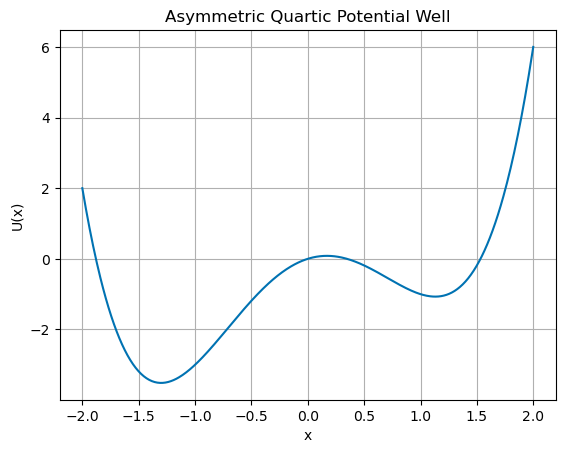

In [ ]:
#3a
#Graphing function to show it fitting criteria provided above

#Setting parameters (subject to change)
a = 1.0
b = 3.0
c = 1.0

#define potential function U
def U(x):
    return a*x**4 - b*x**2 + c*x

#define force function F
#F = -dU/dx
def F(x):
    return -4*a*x**3 + 2*b*x - c

#create x range for function
x = np.linspace(-2, 2, 500)

#plot function
plt.figure()
plt.plot(x, U(x))
plt.xlabel('x')
plt.ylabel('U(x)')
plt.title('Asymmetric Quartic Potential Well')
plt.grid()
plt.show()

#Graph clearly shows at 1 unstable equilibrium point and 2 stable equilibrium points
#Graph also shows oscillatory motion (turning points)
#Graph is continuous and differentiable
#Since graph is differentiable and continuous and F = -dU/dx,
#there is a non-linear, conservative force over this whole potential function.

In [ ]:
#3b
#Finding equilibria, determining stability, and replotting with equilibria

#Coefficients of our force function 4ax^3 - 2bx + c = 0
coeff = [4*a, 0, -2*b, c]

equilibria = np.roots(coeff)

print("Equilibrium points : x=", equilibria)

#Define stability (second derivative) function
def d2u(x):
    return 12*a*x**2 - 2*b

#Determine stable (+d2u) or unstable (-d2u)
for i in equilibria:
    if d2u(i) > 0:
        print(i, 'is a stable equilibrium point')
    else:
        print(i, 'is an unstable equilibrium point')

Equilibrium points : x= [-1.30083957  1.13090112  0.16993844]
-1.3008395659415783 is a stable equilibrium point
1.1309011226299872 is a stable equilibrium point
0.16993844331159125 is an unstable equilibrium point


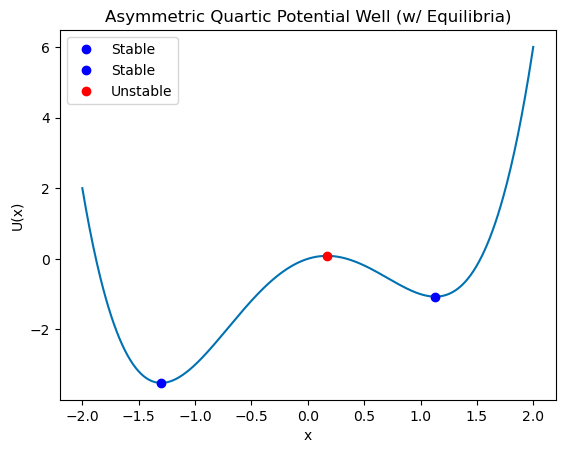

In [ ]:
#Replotting with equilibria
plt.plot(x, U(x))

#Plot stable points and unstable points different colors
for i in equilibria:
    if d2u(i) > 0:
        plt.plot(i, U(i), 'bo', label='Stable')
    else:
        plt.plot(i, U(i), 'ro', label="Unstable")

#Replot graph
plt.xlabel("x")
plt.ylabel('U(x)')
plt.title('Asymmetric Quartic Potential Well (w/ Equilibria)')
plt.legend()
plt.show()

#This graph shows blue points as stable and red points as unstable in the same spots we calculated earlier